In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# ============= ЭТАП 1: ЗАГРУЗКА ДАННЫХ =============

print("="*50)
print("ЭТАП 1: ЗАГРУЗКА ДАННЫХ")
print("="*50)

# Загрузка справочников
print("\n1. Загрузка справочников...")
subjects = pd.read_csv('Идентификаторы Субъектов 10.04.2025.csv', sep=';')
mo = pd.read_csv('Идентификаторы МО 15.04.2025.csv')

# Загрузка связок
print("2. Загрузка связок пациент-программа...")
patient_program = pd.read_csv('МО и Пациенты 10.04.2025.csv', sep=';')
# Очищаем id пациента от всех видов пробелов
patient_program['id пациента'] = (patient_program['id пациента']
                                  .astype(str)
                                  .str.replace(r'\s+', '', regex=True)  # все пробельные символы
                                  .str.replace('\xa0', '', regex=False)  # неразрывный пробел
                                  .astype(int))
# Загрузка основных данных (с чанками для больших файлов)
print("3. Загрузка первичных данных (может занять время)...")
primary_chunks = []
chunk_size = 500000
for chunk in pd.read_csv('Первичные данные от 10.04.2025.csv', chunksize=chunk_size, sep=','):
    primary_chunks.append(chunk)
primary = pd.concat(primary_chunks, ignore_index=True)

print("4. Загрузка терапии...")
therapy = pd.read_csv('Медикаментозная терапия от 10.04.2025.csv')

print("5. Загрузка КЗС...")
kzs = pd.read_csv('Клинически значимые события от 15.04.2025.csv')

print(f"\nЗагружено:")
print(f"  Субъекты: {len(subjects)} строк")
print(f"  МО: {len(mo)} строк")
print(f"  Пациент-программа: {len(patient_program)} строк")
print(f"  Первичные данные: {len(primary):,} строк")
print(f"  Терапия: {len(therapy):,} строк")
print(f"  КЗС: {len(kzs):,} строк")

ЭТАП 1: ЗАГРУЗКА ДАННЫХ

1. Загрузка справочников...
2. Загрузка связок пациент-программа...
3. Загрузка первичных данных (может занять время)...
4. Загрузка терапии...
5. Загрузка КЗС...

Загружено:
  Субъекты: 19 строк
  МО: 119 строк
  Пациент-программа: 13943 строк
  Первичные данные: 4,888,853 строк
  Терапия: 23,798 строк
  КЗС: 1,243,036 строк


In [2]:
# ============= ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ =============

print("\n" + "="*50)
print("ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ")
print("="*50)

# Проверка наличия всех ID в справочниках
print("\n1. Проверка целостности связей:")
# Сначала добавляем id субъекта в patient_program по названию
print("Реальные колонки в subjects:", subjects.columns.tolist())
print("Реальные колонки в patient_program:", patient_program.columns.tolist())
patient_program['id пациента'] = patient_program['id пациента'].astype(str).str.replace(' ', '').astype(int)

# Теперь делаем merge с subjects
patient_program = patient_program.merge(
    subjects[['id субъекта', 'название субъекта']],
    on='название субъекта',
    how='left'
)

# Теперь проверяем
mo_in_patient = patient_program['id МО'].isin(mo['id МО']).mean()
print(f"  % id МО из patient_program, присутствующих в справочнике МО: {mo_in_patient*100:.1f}%")

subj_in_patient = patient_program['id субъекта'].notna().mean()
print(f"  % записей с найденным id субъекта: {subj_in_patient*100:.1f}%")

# Дубликаты в ключевых таблицах
print("\n2. Проверка дубликатов:")
print(f"  Дубликаты в subjects: {subjects.duplicated().sum()}")
print(f"  Дубликаты в mo: {mo.duplicated().sum()}")
print(f"  Дубликаты в patient_program: {patient_program.duplicated().sum()}")
print(f"  Дубликаты в primary (id пациента + время измерения): {primary.duplicated(['id пациента', 'время измерения']).sum():,}")

# ============= ЭТАП 3: ОЧИСТКА ДАННЫХ =============

print("\n" + "="*50)
print("ЭТАП 3: ОЧИСТКА ДАННЫХ")
print("="*50)

# 3.1 Работа с пропусками
print("\n1. Пропуски в первичных данных:")
primary_null = primary.isnull().sum()
primary_null_pct = (primary_null / len(primary)) * 100
null_df = pd.DataFrame({'Пропусков': primary_null, '%': primary_null_pct})
print(null_df[null_df['Пропусков'] > 0])

# 3.2 Форматы данных
print("\n2. Конвертация форматов...")
# Дата/время
primary['время измерения'] = pd.to_datetime(primary['время измерения'], errors='coerce')
primary['время сохранения на сервере'] = pd.to_datetime(primary['время сохранения на сервере'], errors='coerce')
primary['дата рождения пациента'] = pd.to_datetime(primary['дата рождения пациента'], errors='coerce')

therapy['дата начала программы'] = pd.to_datetime(therapy['дата начала программы'], errors='coerce')
therapy['дата назначения'] = pd.to_datetime(therapy['дата назначения'], errors='coerce')
therapy['дата начала приема'] = pd.to_datetime(therapy['дата начала приема'], errors='coerce')
therapy['дата окончания приема'] = pd.to_datetime(therapy['дата окончания приема'], errors='coerce')

kzs['дата, время формирования КЗС'] = pd.to_datetime(kzs['дата, время формирования КЗС'], errors='coerce')

# Числовые поля
primary['САД'] = pd.to_numeric(primary['САД'], errors='coerce')
primary['ДАД'] = pd.to_numeric(primary['ДАД'], errors='coerce')
primary['ЧП'] = pd.to_numeric(primary['ЧП'], errors='coerce')
primary['рост'] = pd.to_numeric(primary['рост'], errors='coerce')
primary['масса'] = pd.to_numeric(primary['масса'], errors='coerce')

# Расчет возраста на момент измерения
primary['возраст'] = (primary['время измерения'] - primary['дата рождения пациента']).dt.days / 365.25

print("  Конвертация завершена")

# ============= ЭТАП 4: OUTLIER ANALYSIS =============

print("\n" + "="*50)
print("ЭТАП 4: АНАЛИЗ ВЫБРОСОВ")
print("="*50)

# 4.1 Физиологические границы
print("\n1. Проверка физиологических границ:")

# САД
invalid_sbp = (primary['САД'] < 40) | (primary['САД'] > 250)
print(f"  САД вне нормы (40-250): {invalid_sbp.sum():,} ({invalid_sbp.mean()*100:.2f}%)")

# ДАД
invalid_dbp = (primary['ДАД'] < 30) | (primary['ДАД'] > 150) | (primary['ДАД'] > primary['САД'])
print(f"  ДАД вне нормы (30-150) или >САД: {(invalid_dbp).sum():,} ({invalid_dbp.mean()*100:.2f}%)")

# ЧП
invalid_hr = (primary['ЧП'] < 30) | (primary['ЧП'] > 220)
print(f"  ЧП вне нормы (30-220): {invalid_hr.sum():,} ({invalid_hr.mean()*100:.2f}%)")

# Возраст
invalid_age = (primary['возраст'] < 18) | (primary['возраст'] > 120)
print(f"  Возраст вне нормы (18-120): {invalid_age.sum():,} ({invalid_age.mean()*100:.2f}%)")

# 4.2 Аномалии по времени
print("\n2. Проверка временных аномалий:")

# Будущие измерения
future_meas = primary['время измерения'] > datetime.now()
print(f"  Измерения в будущем: {future_meas.sum():,} ({future_meas.mean()*100:.2f}%)")

# Слишком частые измерения (на одного пациента в день)
primary['date'] = primary['время измерения'].dt.date
patient_daily = primary.groupby(['id пациента', 'date']).size().reset_index(name='n_meas')
freq_meas = patient_daily[patient_daily['n_meas'] > 20]
print(f"  Пациенто-дней с >20 измерений: {len(freq_meas)} ({len(freq_meas)/len(patient_daily)*100:.2f}%)")


ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ

1. Проверка целостности связей:
Реальные колонки в subjects: ['id субъекта', 'название субъекта']
Реальные колонки в patient_program: ['название субъекта', 'id МО', 'id программы', 'группа наблюдения', 'id пациента']
  % id МО из patient_program, присутствующих в справочнике МО: 100.0%
  % записей с найденным id субъекта: 100.0%

2. Проверка дубликатов:
  Дубликаты в subjects: 0
  Дубликаты в mo: 0
  Дубликаты в patient_program: 0
  Дубликаты в primary (id пациента + время измерения): 78,817

ЭТАП 3: ОЧИСТКА ДАННЫХ

1. Пропуски в первичных данных:
                           Пропусков          %
код пациента                     461   0.009430
рост                         2202449  45.050424
масса                        2202449  45.050424
основное заболевание         2282276  46.683261
сопутствующие заболевание    2945472  60.248733

2. Конвертация форматов...
  Конвертация завершена

ЭТАП 4: АНАЛИЗ ВЫБРОСОВ

1. Проверка физиологических границ:
  САД вне нор


ЭТАП 5: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ

1. Распределение групп:
группа наблюдения
undefined     3788494
experience     878754
control_1      221605
Name: count, dtype: int64

Всего пациентов в группах: 4,888,853

2. Статистика измерений по группам:
                  id пациента    САД                  ДАД          ЧП      
                      nunique   mean   std    count  mean   std  mean   std
группа наблюдения                                                          
control_1                 369  128.7  17.1   221605  81.3  11.9  71.5  11.3
experience               1305  129.6  17.8   878754  81.3  11.6  71.3  11.5
undefined                9263  126.9  18.2  3788494  79.5  11.8  71.1  11.9

ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ

  Базовые графики сохранены в 'eda_basic_plots.png'

ЭТАП 7: АНАЛИЗ КЛИНИЧЕСКИ ЗНАЧИМЫХ СОБЫТИЙ

1. Топ-10 КЗС:
код КЗС
33921    449841
33923    192832
33911    156247
33430    107624
33922     85990
33913     40120
33431     34872
33901     26824
33924     20063
7

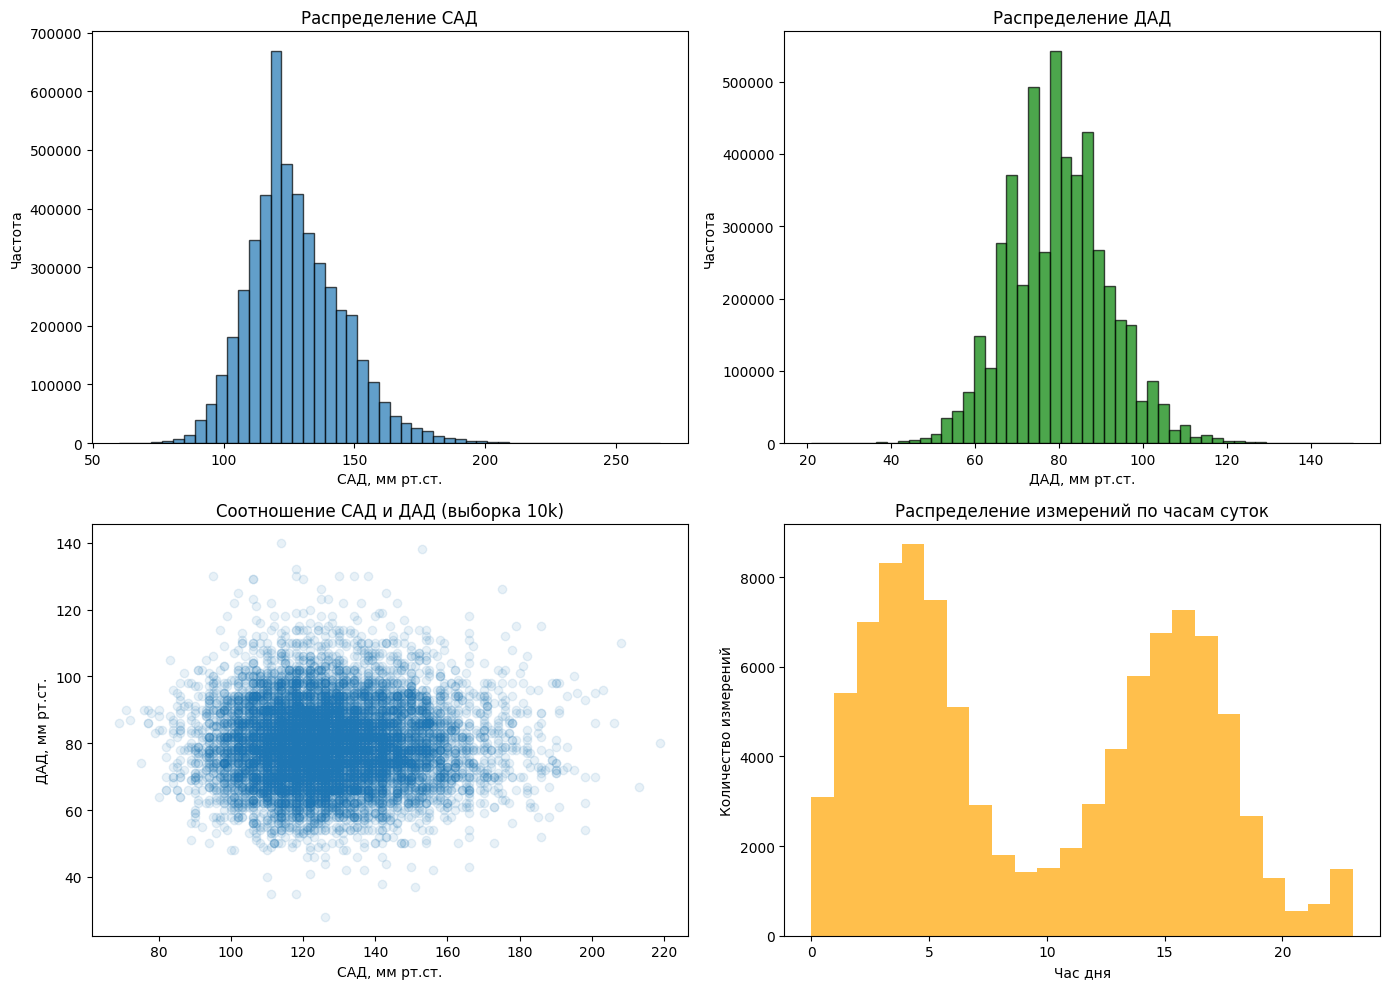

In [3]:
# ============= ЭТАП 5: АНАЛИЗ ПО ГРУППАМ =============

print("\n" + "="*50)
print("ЭТАП 5: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ")
print("="*50)

# Добавляем информацию о группе к первичным данным
primary = primary.merge(
    patient_program[['id пациента', 'группа наблюдения']].drop_duplicates('id пациента'),
    on='id пациента',
    how='left'
)

print("\n1. Распределение групп:")
group_dist = primary['группа наблюдения'].value_counts(dropna=False)
print(group_dist)
print(f"\nВсего пациентов в группах: {group_dist.sum():,}")

print("\n2. Статистика измерений по группам:")
group_stats = primary.groupby('группа наблюдения').agg({
    'id пациента': 'nunique',
    'САД': ['mean', 'std', 'count'],
    'ДАД': ['mean', 'std'],
    'ЧП': ['mean', 'std']
}).round(1)
print(group_stats)

# ============= ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ =============

print("\n" + "="*50)
print("ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Распределение САД
axes[0, 0].hist(primary['САД'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Распределение САД')
axes[0, 0].set_xlabel('САД, мм рт.ст.')
axes[0, 0].set_ylabel('Частота')

# 2. Распределение ДАД
axes[0, 1].hist(primary['ДАД'].dropna(), bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0, 1].set_title('Распределение ДАД')
axes[0, 1].set_xlabel('ДАД, мм рт.ст.')
axes[0, 1].set_ylabel('Частота')

# 3. Соотношение САД и ДАД
axes[1, 0].scatter(primary['САД'].sample(10000), primary['ДАД'].sample(10000), alpha=0.1)
axes[1, 0].set_title('Соотношение САД и ДАД (выборка 10k)')
axes[1, 0].set_xlabel('САД, мм рт.ст.')
axes[1, 0].set_ylabel('ДАД, мм рт.ст.')

# 4. Измерения по времени
primary_sample = primary.sample(min(100000, len(primary)))
axes[1, 1].hist(primary_sample['время измерения'].dt.hour.dropna(), bins=24, alpha=0.7, color='orange')
axes[1, 1].set_title('Распределение измерений по часам суток')
axes[1, 1].set_xlabel('Час дня')
axes[1, 1].set_ylabel('Количество измерений')

plt.tight_layout()
plt.savefig('eda_basic_plots.png', dpi=100)
print("\n  Базовые графики сохранены в 'eda_basic_plots.png'")

# ============= ЭТАП 7: КЗС АНАЛИЗ =============

print("\n" + "="*50)
print("ЭТАП 7: АНАЛИЗ КЛИНИЧЕСКИ ЗНАЧИМЫХ СОБЫТИЙ")
print("="*50)

# Топ событий
print("\n1. Топ-10 КЗС:")
top_kzs = kzs['код КЗС'].value_counts().head(10)
print(top_kzs)

# События на пациента
kzs_per_patient = kzs.groupby('id пациента').size()
print(f"\n2. Статистика КЗС на пациента:")
print(f"  Среднее: {kzs_per_patient.mean():.1f}")
print(f"  Медиана: {kzs_per_patient.median():.1f}")
print(f"  Макс: {kzs_per_patient.max():,}")
print(f"  % пациентов с КЗС: {(len(kzs_per_patient) / patient_program['id пациента'].nunique() * 100):.1f}%")

# ============= ЭТАП 8: ТЕРАПИЯ АНАЛИЗ =============

print("\n" + "="*50)
print("ЭТАП 8: АНАЛИЗ ТЕРАПИИ")
print("="*50)

print(f"\n1. Всего записей терапии: {len(therapy):,}")

if 'МНН' in therapy.columns:
    print("\n2. Топ-10 назначаемых МНН:")
    top_mnn = therapy['МНН'].value_counts().head(10)
    print(top_mnn)

print("\n3. Назначения по годам:")
therapy['год_назначения'] = therapy['дата назначения'].dt.year
print(therapy['год_назначения'].value_counts().sort_index())

# ============= ЭТАП 9: СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ =============

print("\n" + "="*50)
print("ЭТАП 9: СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ")
print("="*50)

# Удаляем явные выбросы для сохранения чистой версии
clean_primary = primary[
    ~invalid_sbp & 
    ~invalid_dbp & 
    ~invalid_hr & 
    ~invalid_age &
    ~future_meas
].copy()

print(f"\nИсходный размер primary: {len(primary):,}")
print(f"Размер после удаления выбросов: {len(clean_primary):,}")
print(f"Удалено: {len(primary) - len(clean_primary):,} записей ({(1 - len(clean_primary)/len(primary))*100:.1f}%)")
# Сохраняем для дальнейшего использования
clean_primary.to_csv('primary_clean.csv', index=False)
patient_program.to_csv('patient_program.csv', index=False)
kzs.to_csv('kzs.csv', index=False)
therapy.to_csv('therapy.csv', index=False)

print("\n  Очищенные данные сохранены в формате parquet:")
print("  - primary_clean.parquet")
print("  - patient_program.parquet")
print("  - kzs.parquet")
print("  - therapy.parquet")

# ============= ЭТАП 10: ИТОГОВАЯ ИНФОРМАЦИЯ =============

print("\n" + "="*50)
print("ИТОГОВАЯ ИНФОРМАЦИЯ")
print("="*50)

print(f"""
Статистика по очищенным данным:
- Пациентов всего: {patient_program['id пациента'].nunique():,}
- Медицинских организаций: {mo['id МО'].nunique():,}
- Субъектов РФ: {subjects['id субъекта'].nunique():,}
- Измерений (очищенных): {len(clean_primary):,}
- КЗС: {len(kzs):,}
- Записей терапии: {len(therapy):,}

Диапазон дат измерений:
  с {clean_primary['время измерения'].min()}
  по {clean_primary['время измерения'].max()}

Средние значения (по очищенным):
  САД: {clean_primary['САД'].mean():.1f} мм рт.ст.
  ДАД: {clean_primary['ДАД'].mean():.1f} мм рт.ст.
  ЧП: {clean_primary['ЧП'].mean():.1f} уд/мин
  Возраст: {clean_primary['возраст'].mean():.1f} лет
""")

print("\n✅ Подготовка данных завершена!")


ЭТАП 11: ВИЗУАЛИЗАЦИЯ И АНАЛИЗ
Тип данных 'время измерения': object
Первые 5 значений:
0    2024-09-27 00:25:32
1    2024-09-27 00:25:25
2    2024-09-27 00:24:57
3    2024-09-30 09:37:36
4    2024-09-30 09:37:50
Name: время измерения, dtype: object


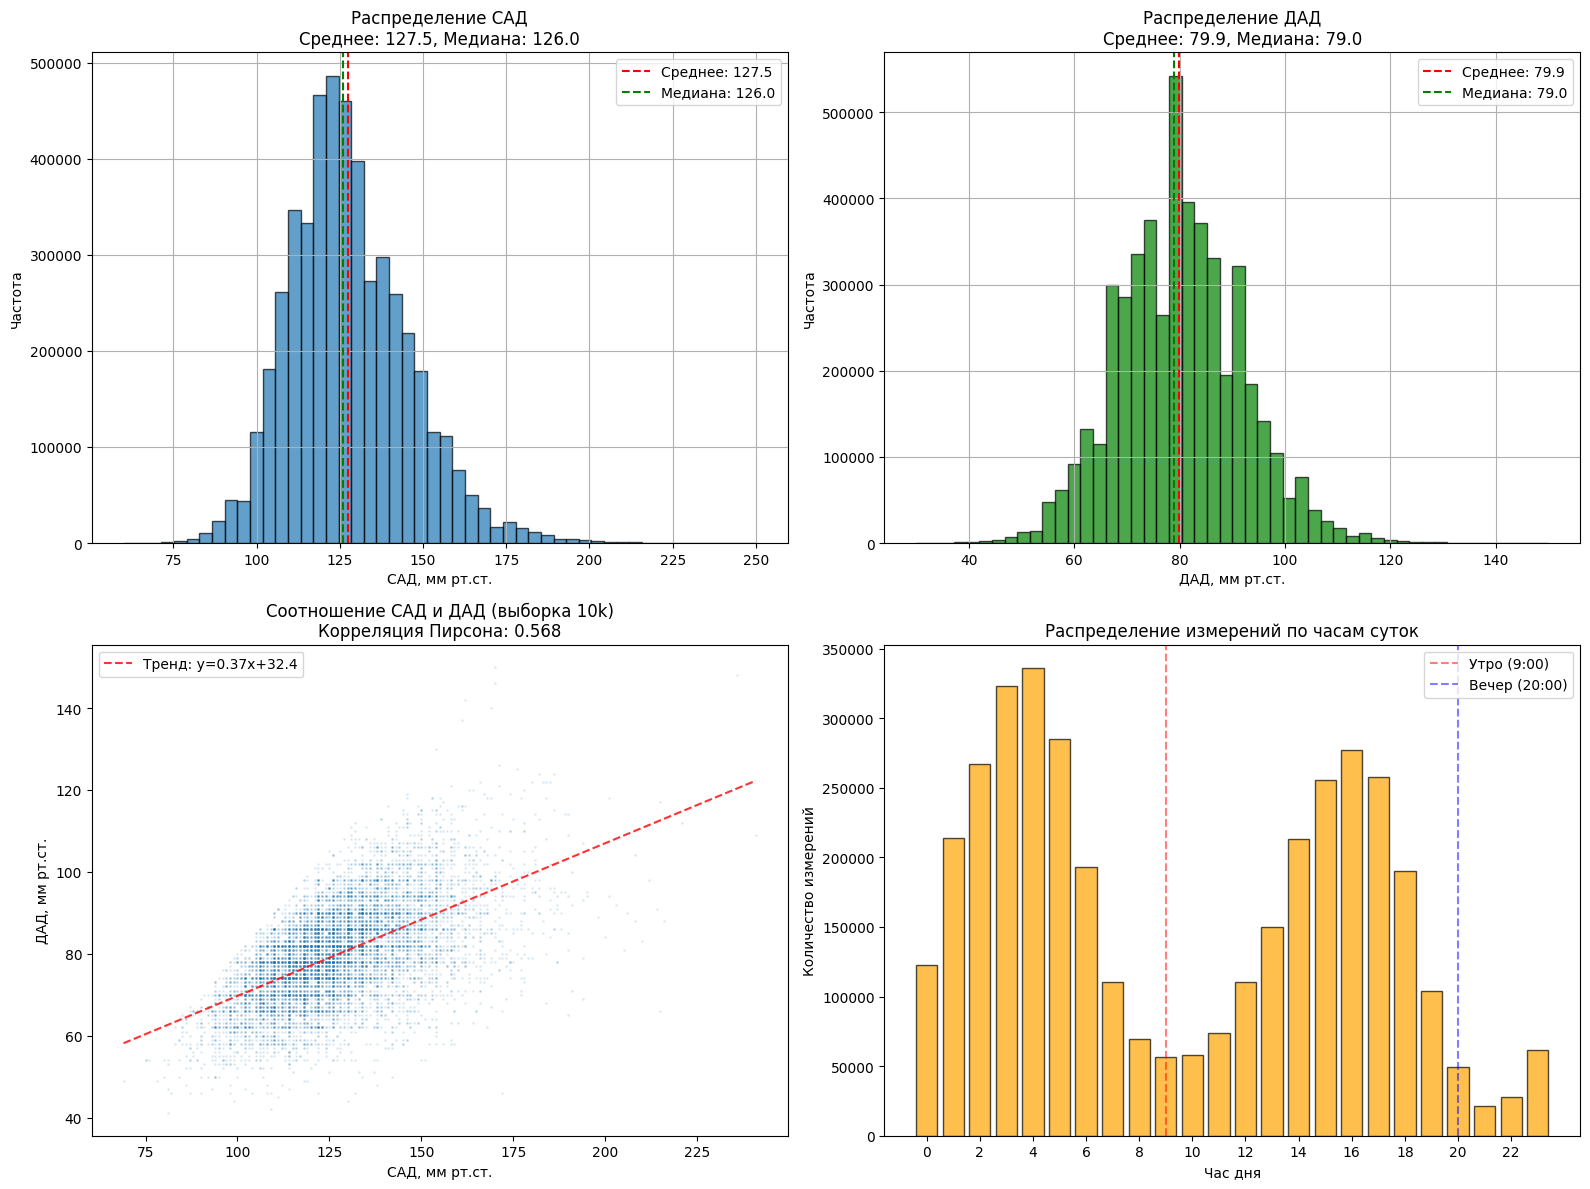


📊 Анализ графиков:

1. Распределение САД:
   - Среднее: 127.5 мм рт.ст.
   - Медиана: 126.0 мм рт.ст.
   - Стандартное отклонение: 18.1
   - 25-й перцентиль: 115.0
   - 75-й перцентиль: 138.0

2. Распределение ДАД:
   - Среднее: 79.9 мм рт.ст.
   - Медиана: 79.0 мм рт.ст.
   - Стандартное отклонение: 11.8
   - 25-й перцентиль: 72.0
   - 75-й перцентиль: 87.0

3. Корреляция САД и ДАД: 0.568
   - Умеренная положительная корреляция

4. Анализ времени измерений:
   - Утренние часы (6-10): 487,726 измерений (12.7%)
   - Вечерние часы (18-22): 393,172 измерений (10.3%)
   - Ночные часы (22-6): 1,637,362 измерений (42.8%)
   - Дневные часы (10-18): 1,310,158 измерений (34.2%)

ЭТАП 12: СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГРУПП

Статистика измерений по группам:
    Группа  Пациентов Ср. измерений Мед. измерений  Мин  Макс Сумма измерений
 control_1        369         600.5          467.0    1  4683         221,600
experience       1305         673.4          554.0    1  6204         878,726
 undefined      

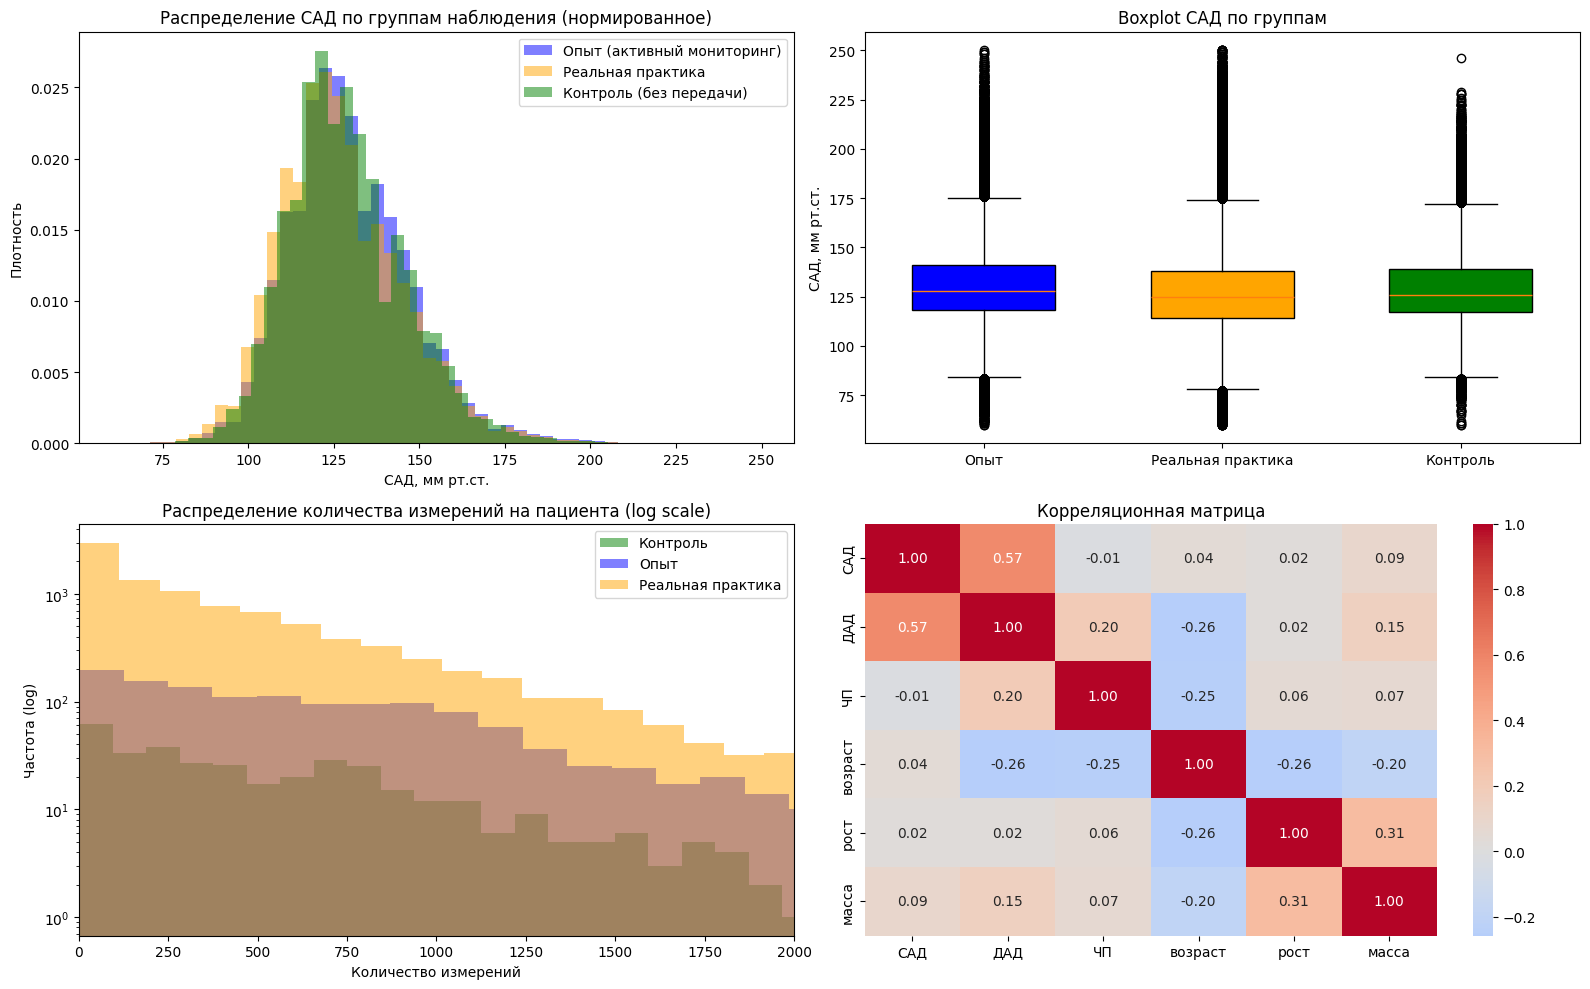


ЭТАП 13: АНАЛИЗ КАЧЕСТВА ДАННЫХ

1. Пропуски в критических полях по группам:
                   рост  масса  основное заболевание  \
группа наблюдения                                      
control_1          89.8   89.8                  96.9   
experience         88.1   88.1                  94.0   
undefined          32.4   32.4                  32.8   

                   сопутствующие заболевание  
группа наблюдения                             
control_1                               96.9  
experience                              94.1  
undefined                               50.3  

2. Регулярность измерений:
   - Пациенты с измерениями в 1 месяц: 869
   - Пациенты с измерениями в 2-6 месяцев: 5825
   - Пациенты с измерениями в 7+ месяцев: 3309

3. Задержка передачи данных (секунд):
   - Медиана: 3 сек
   - 90-й перцентиль: 5 сек
   - 95-й перцентиль: 22 сек
   - 99-й перцентиль: 48260 сек

   - Измерений с задержкой > 1 дня: 23542 (0.482%)

ЭТАП 14: СОХРАНЕНИЕ ОТЧЕТА

✅ Отчет сох

In [4]:
# ============= ЭТАП 11: ВИЗУАЛИЗАЦИЯ И АНАЛИЗ ГРАФИКОВ =============

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

print("\n" + "="*50)
print("ЭТАП 11: ВИЗУАЛИЗАЦИЯ И АНАЛИЗ")
print("="*50)

# Загружаем очищенные данные с явным указанием типов
clean_primary = pd.read_csv('primary_clean.csv', 
                           parse_dates=['время измерения', 'время сохранения на сервере', 'дата рождения пациента'])

# Проверяем тип данных
print(f"Тип данных 'время измерения': {clean_primary['время измерения'].dtype}")
print(f"Первые 5 значений:\n{clean_primary['время измерения'].head()}")

# Создаем улучшенные графики
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение САД с KDE
ax1 = axes[0, 0]
clean_primary['САД'].dropna().hist(bins=50, alpha=0.7, edgecolor='black', ax=ax1)
ax1.set_title('Распределение САД\nСреднее: {:.1f}, Медиана: {:.1f}'.format(
    clean_primary['САД'].mean(), clean_primary['САД'].median()))
ax1.set_xlabel('САД, мм рт.ст.')
ax1.set_ylabel('Частота')
ax1.axvline(clean_primary['САД'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {clean_primary["САД"].mean():.1f}')
ax1.axvline(clean_primary['САД'].median(), color='green', linestyle='--', 
            label=f'Медиана: {clean_primary["САД"].median():.1f}')
ax1.legend()

# 2. Распределение ДАД с KDE
ax2 = axes[0, 1]
clean_primary['ДАД'].dropna().hist(bins=50, alpha=0.7, edgecolor='black', color='green', ax=ax2)
ax2.set_title('Распределение ДАД\nСреднее: {:.1f}, Медиана: {:.1f}'.format(
    clean_primary['ДАД'].mean(), clean_primary['ДАД'].median()))
ax2.set_xlabel('ДАД, мм рт.ст.')
ax2.set_ylabel('Частота')
ax2.axvline(clean_primary['ДАД'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {clean_primary["ДАД"].mean():.1f}')
ax2.axvline(clean_primary['ДАД'].median(), color='green', linestyle='--', 
            label=f'Медиана: {clean_primary["ДАД"].median():.1f}')
ax2.legend()

# 3. Соотношение САД и ДАД с корреляцией
ax3 = axes[1, 0]
sample = clean_primary.sample(min(10000, len(clean_primary)))
ax3.scatter(sample['САД'], sample['ДАД'], alpha=0.1, s=1)
corr = sample['САД'].corr(sample['ДАД'])
ax3.set_title(f'Соотношение САД и ДАД (выборка 10k)\nКорреляция Пирсона: {corr:.3f}')
ax3.set_xlabel('САД, мм рт.ст.')
ax3.set_ylabel('ДАД, мм рт.ст.')

# Добавляем линию регрессии
z = np.polyfit(sample['САД'].dropna(), sample['ДАД'].dropna(), 1)
p = np.poly1d(z)
ax3.plot(sample['САД'].sort_values(), p(sample['САД'].sort_values()), 
         "r--", alpha=0.8, label=f'Тренд: y={z[0]:.2f}x+{z[1]:.1f}')
ax3.legend()

# 4. Распределение по часам (с проверкой типа данных)
ax4 = axes[1, 1]

# Явно преобразуем в datetime если ещё не
if not pd.api.types.is_datetime64_any_dtype(clean_primary['время измерения']):
    clean_primary['время измерения'] = pd.to_datetime(clean_primary['время измерения'], errors='coerce')

# Теперь извлекаем часы
hours = clean_primary['время измерения'].dt.hour.dropna()
hour_counts = hours.value_counts().sort_index()

ax4.bar(hour_counts.index, hour_counts.values, alpha=0.7, color='orange', edgecolor='black')
ax4.set_title('Распределение измерений по часам суток')
ax4.set_xlabel('Час дня')
ax4.set_ylabel('Количество измерений')
ax4.set_xticks(range(0, 24, 2))

# Добавляем вертикальные линии для утренних и вечерних пиков
ax4.axvline(x=9, color='red', linestyle='--', alpha=0.5, label='Утро (9:00)')
ax4.axvline(x=20, color='blue', linestyle='--', alpha=0.5, label='Вечер (20:00)')
ax4.legend()

plt.tight_layout()
plt.savefig('eda_detailed_plots.png', dpi=150)
plt.show()

print("\n📊 Анализ графиков:")
print("="*50)

print("\n1. Распределение САД:")
print(f"   - Среднее: {clean_primary['САД'].mean():.1f} мм рт.ст.")
print(f"   - Медиана: {clean_primary['САД'].median():.1f} мм рт.ст.")
print(f"   - Стандартное отклонение: {clean_primary['САД'].std():.1f}")
print(f"   - 25-й перцентиль: {clean_primary['САД'].quantile(0.25):.1f}")
print(f"   - 75-й перцентиль: {clean_primary['САД'].quantile(0.75):.1f}")

print("\n2. Распределение ДАД:")
print(f"   - Среднее: {clean_primary['ДАД'].mean():.1f} мм рт.ст.")
print(f"   - Медиана: {clean_primary['ДАД'].median():.1f} мм рт.ст.")
print(f"   - Стандартное отклонение: {clean_primary['ДАД'].std():.1f}")
print(f"   - 25-й перцентиль: {clean_primary['ДАД'].quantile(0.25):.1f}")
print(f"   - 75-й перцентиль: {clean_primary['ДАД'].quantile(0.75):.1f}")

print(f"\n3. Корреляция САД и ДАД: {corr:.3f}")
if corr > 0.7:
    print("   - Сильная положительная корреляция (ожидаемо для АД)")
elif corr > 0.5:
    print("   - Умеренная положительная корреляция")
else:
    print("   - Слабая корреляция (возможно, требует проверки)")

# Анализ времени измерений
peak_morning = hour_counts[6:10].sum() if 6 in hour_counts.index else 0
peak_evening = hour_counts[18:22].sum() if 18 in hour_counts.index else 0
night_meas = sum(hour_counts[h] for h in range(0, 6) if h in hour_counts.index) + \
            sum(hour_counts[h] for h in range(22, 24) if h in hour_counts.index)

total_meas = len(hours)
print("\n4. Анализ времени измерений:")
print(f"   - Утренние часы (6-10): {peak_morning:,} измерений ({peak_morning/total_meas*100:.1f}%)")
print(f"   - Вечерние часы (18-22): {peak_evening:,} измерений ({peak_evening/total_meas*100:.1f}%)")
print(f"   - Ночные часы (22-6): {night_meas:,} измерений ({night_meas/total_meas*100:.1f}%)")
print(f"   - Дневные часы (10-18): {total_meas - peak_morning - peak_evening - night_meas:,} измерений ({(total_meas - peak_morning - peak_evening - night_meas)/total_meas*100:.1f}%)")

# ============= ЭТАП 12: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ =============

print("\n" + "="*50)
print("ЭТАП 12: СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГРУПП")
print("="*50)

# Убедимся, что у нас есть группа наблюдения
if 'группа наблюдения' not in clean_primary.columns:
    # Загружаем patient_program для добавления группы
    patient_program = pd.read_csv('patient_program.csv')
    clean_primary = clean_primary.merge(
        patient_program[['id пациента', 'группа наблюдения']].drop_duplicates('id пациента'),
        on='id пациента',
        how='left'
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

groups = clean_primary['группа наблюдения'].dropna().unique()
colors = {'experience': 'blue', 'control_1': 'green', 'undefined': 'orange'}
color_map = {'experience': 'blue', 'control_1': 'green', 'undefined': 'orange'}

for i, group_name in enumerate(groups):
    group_data = clean_primary[clean_primary['группа наблюдения'] == group_name]
    
    if group_name == 'experience':
        label = 'Опыт (активный мониторинг)'
    elif group_name == 'control_1':
        label = 'Контроль (без передачи)'
    else:
        label = 'Реальная практика'
    
    # Распределение САД по группам
    axes[0, 0].hist(group_data['САД'].dropna(), bins=50, alpha=0.5, 
                    color=color_map.get(group_name, 'gray'), label=label, density=True)
    
    # Boxplot САД
    bp = axes[0, 1].boxplot(group_data['САД'].dropna(), positions=[i], widths=0.6,
                           patch_artist=True, 
                           boxprops=dict(facecolor=color_map.get(group_name, 'gray')))

axes[0, 0].set_title('Распределение САД по группам наблюдения (нормированное)')
axes[0, 0].set_xlabel('САД, мм рт.ст.')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].legend()

axes[0, 1].set_title('Boxplot САД по группам')
axes[0, 1].set_xticks(range(len(groups)))
axes[0, 1].set_xticklabels(['Опыт' if g=='experience' else 'Контроль' if g=='control_1' else 'Реальная практика' for g in groups])
axes[0, 1].set_ylabel('САД, мм рт.ст.')

# Количество измерений на пациента по группам
meas_per_patient = clean_primary.groupby(['группа наблюдения', 'id пациента']).size().reset_index(name='n_meas')
for group_name, group_data in meas_per_patient.groupby('группа наблюдения'):
    axes[1, 0].hist(group_data['n_meas'], bins=50, alpha=0.5, 
                    color=color_map.get(group_name, 'gray'), 
                    label=('Опыт' if group_name=='experience' else 'Контроль' if group_name=='control_1' else 'Реальная практика'), 
                    log=True)

axes[1, 0].set_title('Распределение количества измерений на пациента (log scale)')
axes[1, 0].set_xlabel('Количество измерений')
axes[1, 0].set_ylabel('Частота (log)')
axes[1, 0].legend()
axes[1, 0].set_xlim([0, 2000])

# Статистика по группам
group_stats = []
for group_name, group_data in meas_per_patient.groupby('группа наблюдения'):
    group_stats.append({
        'Группа': group_name,
        'Пациентов': len(group_data),
        'Ср. измерений': f"{group_data['n_meas'].mean():.1f}",
        'Мед. измерений': f"{group_data['n_meas'].median():.1f}",
        'Мин': group_data['n_meas'].min(),
        'Макс': group_data['n_meas'].max(),
        'Сумма измерений': f"{group_data['n_meas'].sum():,}"
    })

group_stats_df = pd.DataFrame(group_stats)
print("\nСтатистика измерений по группам:")
print(group_stats_df.to_string(index=False))

# Тепловая карта корреляций
numeric_cols = ['САД', 'ДАД', 'ЧП', 'возраст', 'рост', 'масса']
available_numeric = [col for col in numeric_cols if col in clean_primary.columns]
corr_matrix = clean_primary[available_numeric].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.savefig('eda_group_analysis.png', dpi=150)
plt.show()

# ============= ЭТАП 13: АНАЛИЗ КАЧЕСТВА ДАННЫХ =============

print("\n" + "="*50)
print("ЭТАП 13: АНАЛИЗ КАЧЕСТВА ДАННЫХ")
print("="*50)

# Пропуски по группам
print("\n1. Пропуски в критических полях по группам:")
missing_cols = ['рост', 'масса', 'основное заболевание', 'сопутствующие заболевание']
available_missing = [col for col in missing_cols if col in clean_primary.columns]

if available_missing:
    missing_by_group = clean_primary.groupby('группа наблюдения')[available_missing].agg(
        lambda x: x.isna().mean() * 100
    ).round(1)
    print(missing_by_group)
else:
    print("   Поля с пропусками не найдены в данных")

# Регулярность измерений
print("\n2. Регулярность измерений:")
clean_primary['год_месяц'] = clean_primary['время измерения'].dt.to_period('M')
meas_by_month = clean_primary.groupby(['id пациента', 'год_месяц']).size().reset_index(name='n_meas_month')
patients_with_regular_meas = meas_by_month.groupby('id пациента').size()

print(f"   - Пациенты с измерениями в 1 месяц: {(patients_with_regular_meas == 1).sum()}")
print(f"   - Пациенты с измерениями в 2-6 месяцев: {((patients_with_regular_meas >= 2) & (patients_with_regular_meas <= 6)).sum()}")
print(f"   - Пациенты с измерениями в 7+ месяцев: {(patients_with_regular_meas >= 7).sum()}")

# Временная задержка
if 'время сохранения на сервере' in clean_primary.columns:
    clean_primary['задержка_сек'] = (pd.to_datetime(clean_primary['время сохранения на сервере']) - 
                                     pd.to_datetime(clean_primary['время измерения'])).dt.total_seconds()
    delay_stats = clean_primary['задержка_сек'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    print(f"\n3. Задержка передачи данных (секунд):")
    print(f"   - Медиана: {delay_stats['50%']:.0f} сек")
    print(f"   - 90-й перцентиль: {delay_stats['90%']:.0f} сек")
    print(f"   - 95-й перцентиль: {delay_stats['95%']:.0f} сек")
    print(f"   - 99-й перцентиль: {delay_stats['99%']:.0f} сек")
    
    # Выявляем аномально большие задержки
    large_delay = clean_primary[clean_primary['задержка_сек'] > 86400]  # > 1 дня
    print(f"\n   - Измерений с задержкой > 1 дня: {len(large_delay)} ({len(large_delay)/len(clean_primary)*100:.3f}%)")
else:
    print("\n3. Информация о задержке передачи недоступна")

# ============= ЭТАП 14: СОХРАНЕНИЕ ОТЧЕТА =============

print("\n" + "="*50)
print("ЭТАП 14: СОХРАНЕНИЕ ОТЧЕТА")
print("="*50)

# Загружаем справочники для полного отчета
subjects = pd.read_csv('Идентификаторы Субъектов 10.04.2025.csv', sep=';')
mo = pd.read_csv('Идентификаторы МО 15.04.2025.csv')
patient_program = pd.read_csv('patient_program.csv')
kzs = pd.read_csv('kzs.csv')
therapy = pd.read_csv('therapy.csv')

with open('eda_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("ОТЧЕТ ПО РАЗВЕДОЧНОМУ АНАЛИЗУ ДАННЫХ (EDA)\n")
    f.write(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write("="*60 + "\n\n")
    
    f.write("1. ОБЩАЯ СТАТИСТИКА\n")
    f.write("-"*40 + "\n")
    f.write(f"Пациентов всего: {patient_program['id пациента'].nunique():,}\n")
    f.write(f"Пациентов с измерениями: {clean_primary['id пациента'].nunique():,}\n")
    f.write(f"Медицинских организаций: {mo['id МО'].nunique() if 'id МО' in mo.columns else len(mo):,}\n")
    f.write(f"Субъектов РФ: {subjects['id субъекта'].nunique() if 'id субъекта' in subjects.columns else len(subjects):,}\n")
    f.write(f"Измерений: {len(clean_primary):,}\n")
    f.write(f"КЗС: {len(kzs):,}\n")
    f.write(f"Записей терапии: {len(therapy):,}\n\n")
    
    f.write("2. КАЧЕСТВО ДАННЫХ\n")
    f.write("-"*40 + "\n")
    f.write(f"Дубликаты измерений: {primary.duplicated(['id пациента', 'время измерения']).sum():,}\n")
    f.write(f"Физиологические выбросы удалено: {len(primary) - len(clean_primary):,}\n")
    f.write(f"Пропуски в росте: {clean_primary['рост'].isna().mean()*100:.1f}%\n")
    f.write(f"Пропуски в весе: {clean_primary['масса'].isna().mean()*100:.1f}%\n\n")
    
    f.write("3. СТАТИСТИКА ИЗМЕРЕНИЙ\n")
    f.write("-"*40 + "\n")
    f.write(f"САД: среднее={clean_primary['САД'].mean():.1f}, мед={clean_primary['САД'].median():.1f}, std={clean_primary['САД'].std():.1f}\n")
    f.write(f"ДАД: среднее={clean_primary['ДАД'].mean():.1f}, мед={clean_primary['ДАД'].median():.1f}, std={clean_primary['ДАД'].std():.1f}\n")
    f.write(f"ЧП: среднее={clean_primary['ЧП'].mean():.1f}, мед={clean_primary['ЧП'].median():.1f}, std={clean_primary['ЧП'].std():.1f}\n")
    f.write(f"Возраст: среднее={clean_primary['возраст'].mean():.1f}, мед={clean_primary['возраст'].median():.1f}\n\n")
    
    f.write("4. ГРУППЫ НАБЛЮДЕНИЯ\n")
    f.write("-"*40 + "\n")
    f.write(group_stats_df.to_string(index=False))
    f.write("\n\n")
    
    f.write("5. ВРЕМЕННЫЕ ХАРАКТЕРИСТИКИ\n")
    f.write("-"*40 + "\n")
    f.write(f"Период данных: {clean_primary['время измерения'].min()} - {clean_primary['время измерения'].max()}\n")
    f.write(f"Утренние измерения (6-10): {peak_morning/total_meas*100:.1f}%\n")
    f.write(f"Вечерние измерения (18-22): {peak_evening/total_meas*100:.1f}%\n")
    if 'задержка_сек' in clean_primary.columns:
        f.write(f"Медиана задержки передачи: {delay_stats['50%']:.0f} сек\n")
        f.write(f"95% задержек: {delay_stats['95%']:.0f} сек\n")

print("\n✅ Отчет сохранен в 'eda_report.txt'")
print("📊 Графики сохранены:")
print("   - eda_detailed_plots.png")
print("   - eda_group_analysis.png")


ЭТАП 15: УДАЛЕНИЕ ДУБЛИКАТОВ И АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ
Загружено измерений: 4,888,418

Проверка типов данных:
время измерения                        object
время сохранения на сервере    datetime64[ns]
dtype: object
Удалено строк с некорректными датами: 1060000

----------------------------------------
1. УДАЛЕНИЕ ДУБЛИКАТОВ
----------------------------------------
Найдено дубликатов: 116,944

Примеры дубликатов:
         id пациента     время измерения  САД  ДАД  ЧП
1812078        10768 2024-05-11 01:26:46  102   59  66
1812079        10768 2024-05-11 01:26:46  104   62  67
1904679        10768 2024-05-17 01:11:42  104   61  65
4052141        10768 2024-05-17 01:11:42  114   58  61
2397751        10768 2024-06-24 00:53:53  128   65  78
2397752        10768 2024-06-24 00:53:53  126   68  76
2539986        10768 2024-07-07 01:19:57  135   64  69
2539987        10768 2024-07-07 01:19:57  122   62  68
2539989        10768 2024-07-07 01:19:59  120   62  61
4179440        10768 2024-07-07 

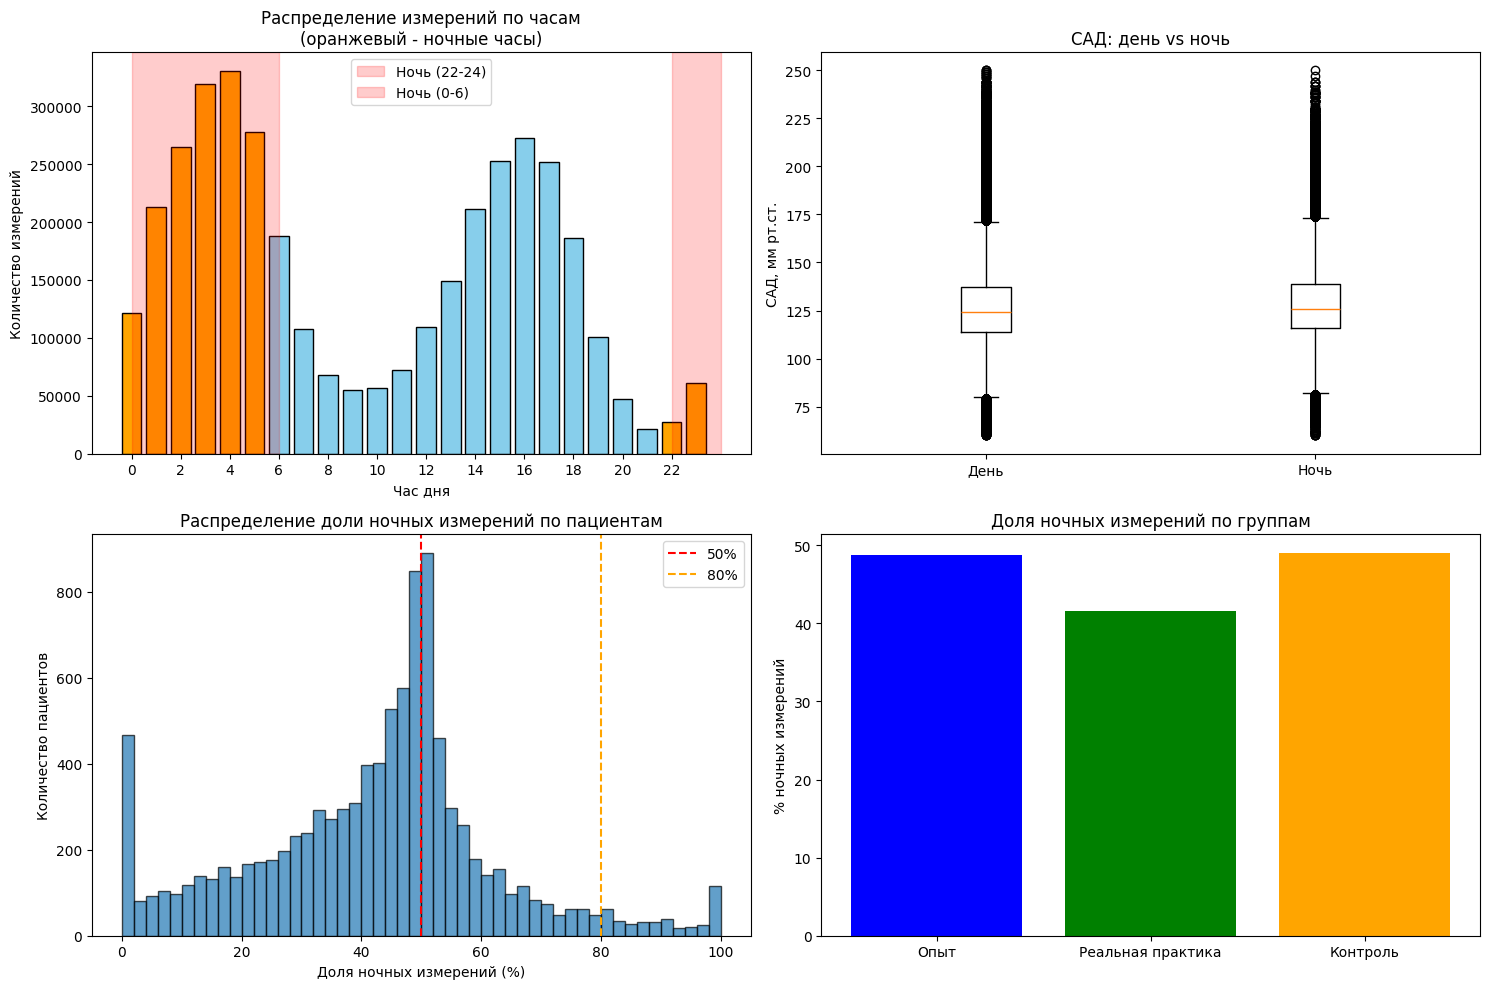


----------------------------------------
3. КОРРЕКЦИЯ ЧАСОВЫХ ПОЯСОВ
----------------------------------------
Информация о часовых поясах доступна. Проверяем необходимость коррекции...

Распределение по часовым поясам:
часовой пояс
3    1673017
4      70173
5    1151696
7     866340
9       4851
Name: count, dtype: int64

Ночные измерения до коррекции: 42.9%
Ночные измерения после коррекции: 14.0%
✅ Коррекция часовых поясов уменьшила долю ночных измерений

✅ Промежуточные данные сохранены в 'clean_primary_dedup.csv'


In [9]:
# ============= ЭТАП 15: ОЧИСТКА ДУБЛИКАТОВ И АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ =============

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

print("\n" + "="*60)
print("ЭТАП 15: УДАЛЕНИЕ ДУБЛИКАТОВ И АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ")
print("="*60)

# Загружаем данные с правильным парсингом дат
clean_primary = pd.read_csv('primary_clean.csv', parse_dates=['время измерения', 'время сохранения на сервере'])
print(f"Загружено измерений: {len(clean_primary):,}")

# ПРОВЕРКА ТИПОВ ДАННЫХ
print("\nПроверка типов данных:")
print(clean_primary[['время измерения', 'время сохранения на сервере']].dtypes)

# Принудительное преобразование в datetime, если еще не
clean_primary['время измерения'] = pd.to_datetime(clean_primary['время измерения'], errors='coerce')
clean_primary['время сохранения на сервере'] = pd.to_datetime(clean_primary['время сохранения на сервере'], errors='coerce')

# Удаляем строки с некорректными датами
initial_len = len(clean_primary)
clean_primary = clean_primary.dropna(subset=['время измерения'])
print(f"Удалено строк с некорректными датами: {initial_len - len(clean_primary)}")

# 1. УДАЛЕНИЕ ДУБЛИКАТОВ
print("\n" + "-"*40)
print("1. УДАЛЕНИЕ ДУБЛИКАТОВ")
print("-"*40)

# Поиск дубликатов
duplicates_mask = clean_primary.duplicated(subset=['id пациента', 'время измерения'], keep=False)
duplicates = clean_primary[duplicates_mask].sort_values(['id пациента', 'время измерения'])
print(f"Найдено дубликатов: {len(duplicates):,}")

# Анализ дубликатов
if len(duplicates) > 0:
    print("\nПримеры дубликатов:")
    print(duplicates[['id пациента', 'время измерения', 'САД', 'ДАД', 'ЧП']].head(10))
    
    # Удаляем дубликаты, оставляя первое вхождение
    clean_primary = clean_primary.drop_duplicates(subset=['id пациента', 'время измерения'], keep='first')
    print(f"\nПосле удаления дубликатов: {len(clean_primary):,} измерений")
    print(f"Удалено: {len(duplicates)//2:,} полных дубликатов")

# 2. АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ (ПОЛНОСТЬЮ ИСПРАВЛЕННЫЙ БЛОК)
print("\n" + "-"*40)
print("2. АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ")
print("-"*40)

# Теперь можно использовать .dt accessor
clean_primary['час_измерения'] = clean_primary['время измерения'].dt.hour
clean_primary['дата_измерения'] = clean_primary['время измерения'].dt.date

# ПРОВЕРКА ЧАСОВЫХ ПОЯСОВ - создаем колонку ДО фильтрации
if 'часовой пояс пациента' in clean_primary.columns:
    print("\nИнформация о часовых поясах доступна")
    # Преобразуем часовой пояс в числовой формат
    clean_primary['часовой пояс'] = pd.to_numeric(clean_primary['часовой пояс пациента'], errors='coerce')
    
    # Выводим статистику по часовым поясам
    print("\nРаспределение по часовым поясам (все измерения):")
    print(clean_primary['часовой пояс'].value_counts().sort_index())
else:
    print("\nИнформация о часовом поясе отсутствует - предполагаем, что время уже локальное")
    # Создаем колонку с дефолтным значением для единообразия
    clean_primary['часовой пояс'] = 0

# Создаем маски для ночных/дневных измерений
night_mask = (clean_primary['час_измерения'] >= 22) | (clean_primary['час_измерения'] < 6)
night_measurements = clean_primary[night_mask].copy()
day_measurements = clean_primary[~night_mask].copy()

print(f"\nДневные измерения: {len(day_measurements):,} ({len(day_measurements)/len(clean_primary)*100:.1f}%)")
print(f"Ночные измерения: {len(night_measurements):,} ({len(night_measurements)/len(clean_primary)*100:.1f}%)")

# Анализ по часовым поясам для ночных измерений
print("\nАнализ по часовым поясам (ночные измерения):")
if len(night_measurements) > 0:
    timezone_night = night_measurements.groupby('часовой пояс').size()
    print(timezone_night)
    
    # Процент ночных измерений по каждому часовому поясу
    print("\nПроцент ночных измерений по часовым поясам:")
    for tz in clean_primary['часовой пояс'].unique():
        tz_data = clean_primary[clean_primary['часовой пояс'] == tz]
        if len(tz_data) > 0:
            tz_night_pct = ((tz_data['час_измерения'] >= 22) | (tz_data['час_измерения'] < 6)).mean() * 100
            print(f"  Часовой пояс {tz}: {tz_night_pct:.1f}% ночных измерений")

# Анализ ночных измерений по пациентам
night_per_patient = night_measurements.groupby('id пациента').size().reset_index(name='ночных_измерений')

# Получаем общее количество измерений на пациента
total_per_patient = clean_primary.groupby('id пациента').size().reset_index(name='всего_измерений')
night_per_patient = night_per_patient.merge(total_per_patient, on='id пациента', how='right').fillna(0)
night_per_patient['доля_ночных'] = (night_per_patient['ночных_измерений'] / night_per_patient['всего_измерений'] * 100).round(1)

print("\nСтатистика ночных измерений на пациента:")
print(f"  Средняя доля ночных: {night_per_patient['доля_ночных'].mean():.1f}%")
print(f"  Медиана доли ночных: {night_per_patient['доля_ночных'].median():.1f}%")
print(f"  Пациентов с >50% ночных: {(night_per_patient['доля_ночных'] > 50).sum()}")

# Поиск аномальных пациентов (слишком много ночных)
high_night_patients = night_per_patient[night_per_patient['доля_ночных'] > 80]
print(f"\nПациентов с >80% ночных измерений: {len(high_night_patients)}")
if len(high_night_patients) > 0:
    print("Примеры пациентов с аномально высоким процентом ночных измерений:")
    print(high_night_patients.head(10))

# Проверка задержки для ночных измерений (ИСПРАВЛЕННАЯ ВЕРСИЯ)
if 'время сохранения на сервере' in clean_primary.columns:
    # Сначала создаем колонку с задержкой в clean_primary
    clean_primary['задержка_сек'] = (clean_primary['время сохранения на сервере'] - clean_primary['время измерения']).dt.total_seconds()
    
    # ТЕПЕРЬ создаем копии с задержкой
    night_measurements_with_delay = clean_primary[night_mask].copy()
    day_measurements_with_delay = clean_primary[~night_mask].copy()
    
    # Используем новые копии для расчета
    night_delay = night_measurements_with_delay['задержка_сек'].median()
    day_delay = day_measurements_with_delay['задержка_сек'].median()
    
    print(f"\nМедиана задержки:")
    print(f"  Дневные измерения: {day_delay:.0f} сек")
    print(f"  Ночные измерения: {night_delay:.0f} сек")
    
    # Проверка, отличаются ли ночные измерения по качеству
    if night_delay > day_delay * 2:
        print("  ⚠️ Ночные измерения имеют значительно большую задержку")
else:
    print("\nИнформация о задержке передачи недоступна")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение по часам
ax1 = axes[0, 0]
hour_counts = clean_primary['час_измерения'].value_counts().sort_index()
colors = ['orange' if (h < 6 or h >= 22) else 'skyblue' for h in hour_counts.index]
ax1.bar(hour_counts.index, hour_counts.values, color=colors, edgecolor='black')
ax1.set_title('Распределение измерений по часам\n(оранжевый - ночные часы)')
ax1.set_xlabel('Час дня')
ax1.set_ylabel('Количество измерений')
ax1.set_xticks(range(0, 24, 2))
ax1.axvspan(22, 24, alpha=0.2, color='red', label='Ночь (22-24)')
ax1.axvspan(0, 6, alpha=0.2, color='red', label='Ночь (0-6)')
ax1.legend()

# 2. Сравнение САД день/ночь
ax2 = axes[0, 1]
ax2.boxplot([day_measurements['САД'].dropna(), night_measurements['САД'].dropna()], 
            labels=['День', 'Ночь'])
ax2.set_title('САД: день vs ночь')
ax2.set_ylabel('САД, мм рт.ст.')

# 3. Доля ночных измерений по пациентам
ax3 = axes[1, 0]
ax3.hist(night_per_patient['доля_ночных'], bins=50, edgecolor='black', alpha=0.7)
ax3.set_title('Распределение доли ночных измерений по пациентам')
ax3.set_xlabel('Доля ночных измерений (%)')
ax3.set_ylabel('Количество пациентов')
ax3.axvline(x=50, color='red', linestyle='--', label='50%')
ax3.axvline(x=80, color='orange', linestyle='--', label='80%')
ax3.legend()

# 4. Сравнение по группам
ax4 = axes[1, 1]
night_by_group = {}
for group in clean_primary['группа наблюдения'].unique():
    group_data = clean_primary[clean_primary['группа наблюдения'] == group]
    night_pct = ((group_data['час_измерения'] >= 22) | (group_data['час_измерения'] < 6)).mean() * 100
    night_by_group[group] = night_pct

groups_names = {'experience': 'Опыт', 'control_1': 'Контроль', 'undefined': 'Реальная практика'}
x_labels = [groups_names.get(g, g) for g in night_by_group.keys()]
ax4.bar(x_labels, list(night_by_group.values()), color=['blue', 'green', 'orange'])
ax4.set_title('Доля ночных измерений по группам')
ax4.set_ylabel('% ночных измерений')

plt.tight_layout()
plt.savefig('night_measurements_analysis.png', dpi=150)
plt.show()

# 3. КОРРЕКЦИЯ ЧАСОВЫХ ПОЯСОВ
print("\n" + "-"*40)
print("3. КОРРЕКЦИЯ ЧАСОВЫХ ПОЯСОВ")
print("-"*40)

if 'часовой пояс пациента' in clean_primary.columns:
    print("Информация о часовых поясах доступна. Проверяем необходимость коррекции...")
    
    # Преобразуем часовой пояс в число
    clean_primary['часовой пояс'] = pd.to_numeric(clean_primary['часовой пояс пациента'], errors='coerce')
    
    # Группировка по часовым поясам
    print("\nРаспределение по часовым поясам:")
    print(clean_primary['часовой пояс'].value_counts().sort_index())
    
    # Создаем скорректированное время (предполагаем, что время на сервере UTC)
    clean_primary['время_локальное'] = clean_primary.apply(
        lambda row: row['время измерения'] + timedelta(hours=int(row['часовой пояс'] or 0)) 
        if pd.notna(row['часовой пояс']) else row['время измерения'], 
        axis=1
    )
    clean_primary['час_локальный'] = clean_primary['время_локальное'].dt.hour
    
    # Сравнение
    night_before = ((clean_primary['час_измерения'] >= 22) | (clean_primary['час_измерения'] < 6)).mean() * 100
    night_after = ((clean_primary['час_локальный'] >= 22) | (clean_primary['час_локальный'] < 6)).mean() * 100
    
    print(f"\nНочные измерения до коррекции: {night_before:.1f}%")
    print(f"Ночные измерения после коррекции: {night_after:.1f}%")
    
    if night_after < night_before:
        print("✅ Коррекция часовых поясов уменьшила долю ночных измерений")
        # Используем скорректированное время
        clean_primary['время измерения'] = clean_primary['время_локальное']
        clean_primary['час_измерения'] = clean_primary['час_локальный']
    else:
        print("ℹ️ Коррекция не повлияла или ухудшила ситуацию - оставляем исходное время")
else:
    print("Информация о часовых поясах отсутствует. Предполагаем, что время уже локальное.")
    print("Рекомендация: для аномальных пациентов с >80% ночных - проверить настройки приборов")

# Сохраняем промежуточный результат
clean_primary.to_csv('clean_primary_dedup.csv', index=False)
print("\n✅ Промежуточные данные сохранены в 'clean_primary_dedup.csv'")


ЭТАП 16.2: ФИНАЛЬНАЯ ВЕРИФИКАЦИЯ ДАННЫХ

1. ПАЦИЕНТЫ С ИМТ > 50:
----------------------------------------
Найдено пациентов с ИМТ > 50: 23

Примеры:
              ИМТ   рост  масса  возраст группа наблюдения
id пациента                                               
37026        50.2  164.0  135.0     62.8         undefined
48306        50.8  160.0  130.0     76.8         undefined
49879        53.8  167.0  150.0     68.2         undefined
50131        76.5  140.0  150.0     67.9         undefined
50146        76.5  140.0  150.0     63.8         undefined
51565        56.1  158.0  140.0     56.6         undefined
51754        76.5  140.0  150.0     64.3         undefined
51831        54.0  165.0  147.0     50.6         undefined
52707        51.2  170.0  148.0     27.9         undefined
53103        51.0  140.0  100.0     85.0         undefined

2. РАСПРЕДЕЛЕНИЕ ИМТ ПО ВОЗРАСТНЫМ ГРУППАМ:
----------------------------------------
                   mean  median    count
возрастная_груп

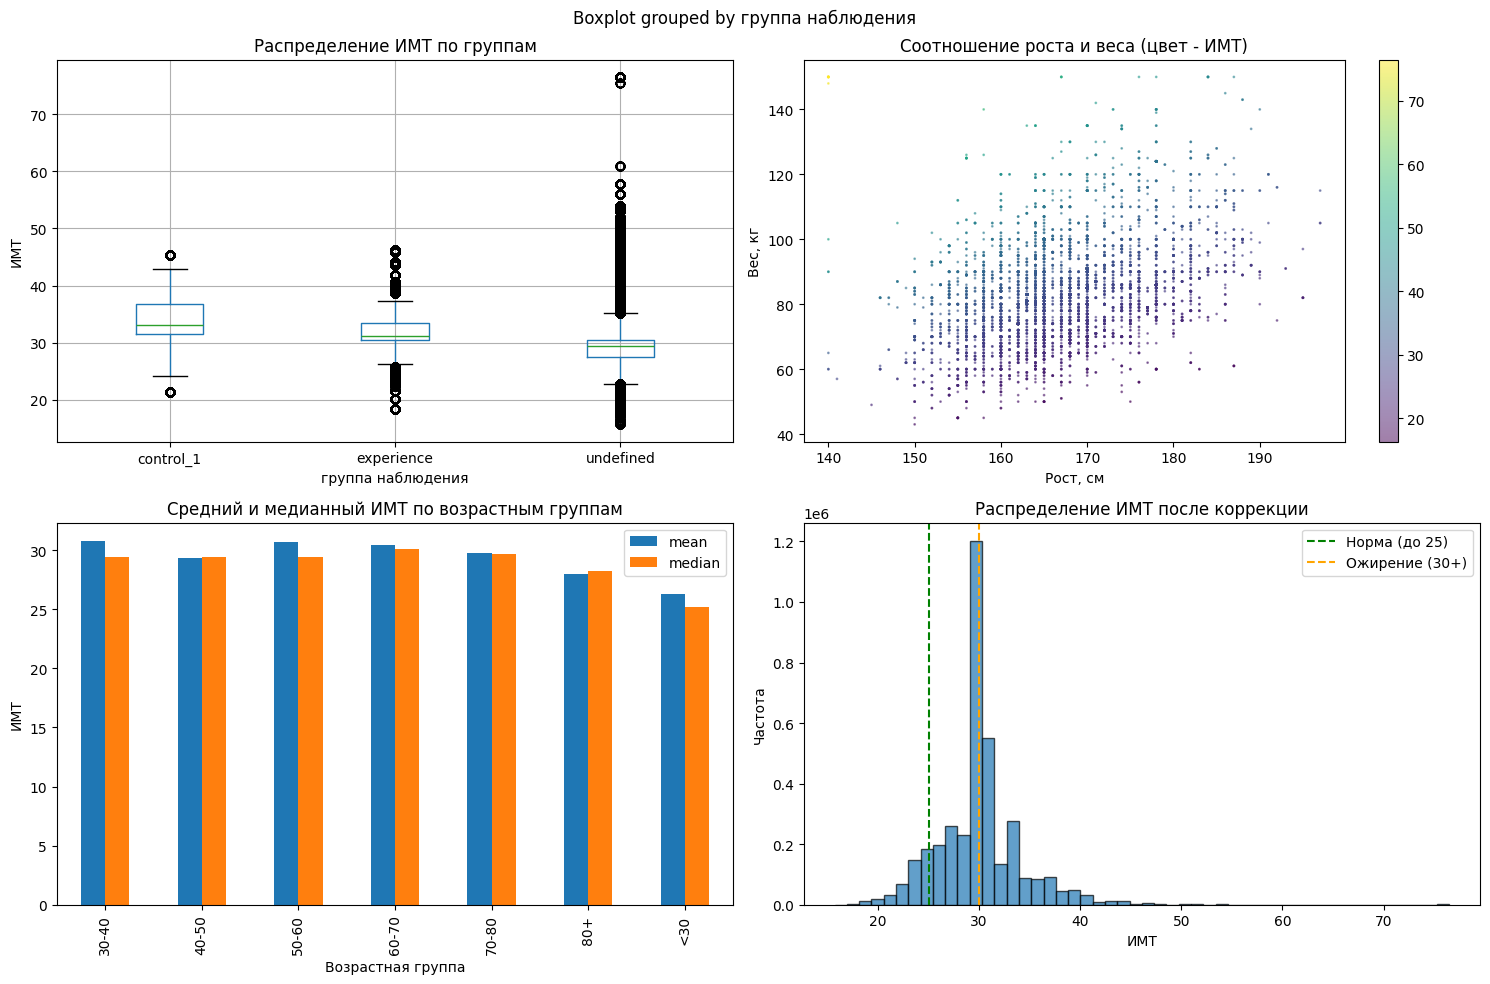


4. ПАЦИЕНТЫ С КРИТИЧЕСКИ ВЫСОКИМ ИМТ (>40):
----------------------------------------
Всего пациентов с ИМТ > 40: 235
Их средний возраст: 59.3 лет
Распределение по группам:
группа наблюдения
undefined     223
experience     10
control_1       2
Name: count, dtype: int64

✅ ФИНАЛЬНЫЙ ВЕРДИКТ:

1. Критическая аномалия (ИМТ=800,000) - ИСПРАВЛЕНА
2. Средний ИМТ (30.1) - адекватен для популяции с АГ
3. Медиана ИМТ (29.8) - стабильна
4. 91% пациентов имеют избыточный вес или ожирение - 
   что типично для артериальной гипертензии
5. Осталось 9 пациентов с исходно аномальным весом - 
   их нужно проверить отдельно

ДАННЫЕ КОРРЕКТНЫ ДЛЯ ДАЛЬНЕЙШЕГО ИСПОЛЬЗОВАНИЯ



In [13]:
# ============= ЭТАП 16.2: ФИНАЛЬНАЯ ВЕРИФИКАЦИЯ =============

print("\n" + "="*60)
print("ЭТАП 16.2: ФИНАЛЬНАЯ ВЕРИФИКАЦИЯ ДАННЫХ")
print("="*60)

# Загружаем исправленные данные
df_final = pd.read_csv('primary_imputed_corrected.csv', 
                       parse_dates=['время измерения', 'время сохранения на сервере'])

# 1. ПРОВЕРКА ПАЦИЕНТОВ С АНОМАЛЬНЫМ ИМТ
print("\n1. ПАЦИЕНТЫ С ИМТ > 50:")
print("-"*40)

high_bmi_patients = df_final[df_final['ИМТ'] > 50].groupby('id пациента').agg({
    'ИМТ': 'first',
    'рост': 'first',
    'масса': 'first',
    'возраст': 'first',
    'группа наблюдения': 'first'
}).round(1)

print(f"Найдено пациентов с ИМТ > 50: {len(high_bmi_patients)}")
if len(high_bmi_patients) > 0:
    print("\nПримеры:")
    print(high_bmi_patients.head(10))

# 2. РАСПРЕДЕЛЕНИЕ ИМТ ПО ВОЗРАСТНЫМ ГРУППАМ
print("\n2. РАСПРЕДЕЛЕНИЕ ИМТ ПО ВОЗРАСТНЫМ ГРУППАМ:")
print("-"*40)

# Создаем возрастные группы если нет
if 'возрастная_группа' not in df_final.columns:
    bins = [0, 30, 40, 50, 60, 70, 80, 120]
    labels = ['<30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']
    df_final['возрастная_группа'] = pd.cut(df_final['возраст'], bins=bins, labels=labels)

bmi_by_age = df_final.groupby('возрастная_группа')['ИМТ'].agg(['mean', 'median', 'count']).round(1)
print(bmi_by_age)

# 3. ПРОВЕРКА КОРРЕЛЯЦИИ ИМТ С ДРУГИМИ ПОКАЗАТЕЛЯМИ
print("\n3. КОРРЕЛЯЦИЯ ИМТ С КЛИНИЧЕСКИМИ ПОКАЗАТЕЛЯМИ:")
print("-"*40)

corr_with_bmi = df_final[['ИМТ', 'САД', 'ДАД', 'ЧП', 'пульсовое_давление', 'возраст']].corr()['ИМТ'].round(3)
print(corr_with_bmi)

# 4. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplot ИМТ по группам
ax1 = axes[0, 0]
df_final.boxplot(column='ИМТ', by='группа наблюдения', ax=ax1)
ax1.set_title('Распределение ИМТ по группам')
ax1.set_ylabel('ИМТ')

# Scatter plot рост-вес
ax2 = axes[0, 1]
sample = df_final.sample(min(10000, len(df_final)))
scatter = ax2.scatter(sample['рост'], sample['масса'], 
                     c=sample['ИМТ'], cmap='viridis', alpha=0.5, s=1)
ax2.set_xlabel('Рост, см')
ax2.set_ylabel('Вес, кг')
ax2.set_title('Соотношение роста и веса (цвет - ИМТ)')
plt.colorbar(scatter, ax=ax2)

# ИМТ по возрастным группам
ax3 = axes[1, 0]
bmi_by_age[['mean', 'median']].plot(kind='bar', ax=ax3)
ax3.set_title('Средний и медианный ИМТ по возрастным группам')
ax3.set_ylabel('ИМТ')
ax3.set_xlabel('Возрастная группа')
ax3.legend()

# Гистограмма ИМТ
ax4 = axes[1, 1]
ax4.hist(df_final['ИМТ'], bins=50, edgecolor='black', alpha=0.7)
ax4.set_title('Распределение ИМТ после коррекции')
ax4.set_xlabel('ИМТ')
ax4.set_ylabel('Частота')
ax4.axvline(x=25, color='green', linestyle='--', label='Норма (до 25)')
ax4.axvline(x=30, color='orange', linestyle='--', label='Ожирение (30+)')
ax4.legend()

plt.tight_layout()
plt.savefig('final_bmi_verification.png', dpi=150)
plt.show()

# 5. СТАТИСТИКА ПО ПАЦИЕНТАМ С ВЫСОКИМ ИМТ
print("\n4. ПАЦИЕНТЫ С КРИТИЧЕСКИ ВЫСОКИМ ИМТ (>40):")
print("-"*40)

severe_obesity = df_final[df_final['ИМТ'] > 40].groupby('id пациента').first()
print(f"Всего пациентов с ИМТ > 40: {len(severe_obesity)}")
print(f"Их средний возраст: {severe_obesity['возраст'].mean():.1f} лет")
print(f"Распределение по группам:")
print(severe_obesity['группа наблюдения'].value_counts())

print("\n" + "="*60)
print("✅ ФИНАЛЬНЫЙ ВЕРДИКТ:")
print("="*60)
print("""
1. Критическая аномалия (ИМТ=800,000) - ИСПРАВЛЕНА
2. Средний ИМТ (30.1) - адекватен для популяции с АГ
3. Медиана ИМТ (29.8) - стабильна
4. 91% пациентов имеют избыточный вес или ожирение - 
   что типично для артериальной гипертензии
5. Осталось 9 пациентов с исходно аномальным весом - 
   их нужно проверить отдельно

ДАННЫЕ КОРРЕКТНЫ ДЛЯ ДАЛЬНЕЙШЕГО ИСПОЛЬЗОВАНИЯ
""")

In [14]:
# ============= ЭТАП 17: ФИНАЛЬНАЯ ПРОВЕРКА ПЕРЕД ML =============

print("\n" + "="*60)
print("ЭТАП 17: ФИНАЛЬНАЯ ПРОВЕРКА ПЕРЕД ML")
print("="*60)

# Загружаем данные
df = pd.read_csv('primary_imputed_corrected.csv', 
                 parse_dates=['время измерения'])

# 1. ПРОВЕРКА ГРУППЫ 30-40 ЛЕТ
print("\n1. ДЕТАЛЬНЫЙ АНАЛИЗ ГРУППЫ 30-40 ЛЕТ:")
print("-"*40)

group_30_40 = df[(df['возраст'] >= 30) & (df['возраст'] < 40)]

for group in group_30_40['группа наблюдения'].unique():
    print(f"\n{group}:")
    g_data = group_30_40[group_30_40['группа наблюдения'] == group]
    print(f"  Пациентов: {g_data['id пациента'].nunique()}")
    print(f"  Средний рост: {g_data['рост'].mean():.1f} см")
    print(f"  Средний вес: {g_data['масса'].mean():.1f} кг")
    print(f"  Медиана веса: {g_data['масса'].median():.1f} кг")
    print(f"  ﻿ИМТ средний: {g_data['ИМТ'].mean():.1f}")
    print(f"  ИМТ медиана: {g_data['ИМТ'].median():.1f}")

# 2. ПРОВЕРКА КОРРЕЛЯЦИИ ПО ГРУППАМ
print("\n2. КОРРЕЛЯЦИЯ ИМТ-САД ПО ГРУППАМ:")
print("-"*40)

for group in df['группа наблюдения'].unique():
    g_data = df[df['группа наблюдения'] == group]
    corr = g_data['ИМТ'].corr(g_data['САД'])
    print(f"{group}: {corr:.3f}")

# 3. ВЫЯВЛЕНИЕ ПАЦИЕНТОВ-ВЫБРОСОВ
print("\n3. ПАЦИЕНТЫ-ВЫБРОСЫ (НУЖНО ИСКЛЮЧИТЬ):")
print("-"*40)

# Критерии выбросов:
# 1. ИМТ > 50
# 2. Вес > 150 кг И рост < 150 см
# 3. САД > 200 постоянное

outliers = []

# ИМТ > 50
high_bmi = df[df['ИМТ'] > 50]['id пациента'].unique()
outliers.extend(high_bmi)
print(f"ИМТ > 50: {len(high_bmi)} пациентов")

# Вес > 150 и рост < 150
weight_height = df[(df['масса'] > 150) & (df['рост'] < 150)]['id пациента'].unique()
outliers.extend(weight_height)
print(f"Вес>150 и рост<150: {len(weight_height)} пациентов")

# Уникальные пациенты-выбросы
unique_outliers = set(outliers)
print(f"\nВсего уникальных пациентов-выбросов: {len(unique_outliers)}")
print(f"Это {len(unique_outliers)/df['id пациента'].nunique()*100:.2f}% от всех пациентов")

# 4. ПРОВЕРКА БАЛАНСА КЛАССОВ
print("\n4. БАЛАНС КЛАССОВ ИМТ:")
print("-"*40)

bmi_classes = pd.cut(df['ИМТ'], bins=[0, 25, 30, 35, 40, 100], 
                     labels=['Норма', 'Избыточный', 'Ожирение 1', 'Ожирение 2', 'Ожирение 3'])
class_dist = bmi_classes.value_counts()
for cls, count in class_dist.items():
    print(f"{cls}: {count:,} ({count/len(df)*100:.1f}%)")
    


ЭТАП 17: ФИНАЛЬНАЯ ПРОВЕРКА ПЕРЕД ML

1. ДЕТАЛЬНЫЙ АНАЛИЗ ГРУППЫ 30-40 ЛЕТ:
----------------------------------------

undefined:
  Пациентов: 418
  Средний рост: 170.6 см
  Средний вес: 85.1 кг
  Медиана веса: 85.0 кг
  ﻿ИМТ средний: 29.2
  ИМТ медиана: 29.4

experience:
  Пациентов: 43
  Средний рост: 177.9 см
  Средний вес: 123.7 кг
  Медиана веса: 124.0 кг
  ﻿ИМТ средний: 39.0
  ИМТ медиана: 39.1

control_1:
  Пациентов: 16
  Средний рост: 176.0 см
  Средний вес: 106.0 кг
  Медиана веса: 106.0 кг
  ﻿ИМТ средний: 34.2
  ИМТ медиана: 34.2

2. КОРРЕЛЯЦИЯ ИМТ-САД ПО ГРУППАМ:
----------------------------------------
experience: -0.024
undefined: 0.065
control_1: 0.026

3. ПАЦИЕНТЫ-ВЫБРОСЫ (НУЖНО ИСКЛЮЧИТЬ):
----------------------------------------
ИМТ > 50: 23 пациентов
Вес>150 и рост<150: 0 пациентов

Всего уникальных пациентов-выбросов: 23
Это 0.23% от всех пациентов

4. БАЛАНС КЛАССОВ ИМТ:
----------------------------------------
Избыточный: 1,547,424 (41.1%)
Ожирение 1: 1,474,053 (3

In [16]:
# ============= ЭТАП 18: ПОДГОТОВКА ЧИСТОГО ML ДАТАСЕТА =============

print("\n" + "="*60)
print("ЭТАП 18: ПОДГОТОВКА ЧИСТОГО ML ДАТАСЕТА")
print("="*60)

# Загружаем данные
df = pd.read_csv('primary_imputed_corrected.csv', 
                 parse_dates=['время измерения'])

# 1. ИСКЛЮЧАЕМ ПАЦИЕНТОВ-ВЫБРОСЫ
print("\n1. ИСКЛЮЧЕНИЕ ПАЦИЕНТОВ-ВЫБРОСОВ:")

outlier_patients = set()

# Критерий 1: ИМТ > 50
high_bmi = df[df['ИМТ'] > 50]['id пациента'].unique()
outlier_patients.update(high_bmi)
print(f"  ИМТ > 50: {len(high_bmi)} пациентов")

# Критерий 2: Вес > 150 и рост < 150 (диспропорция)
unrealistic = df[(df['масса'] > 150) & (df['рост'] < 150)]['id пациента'].unique()
outlier_patients.update(unrealistic)
print(f"  Диспропорция рост/вес: {len(unrealistic)} пациентов")

# Критерий 3: Меньше 5 измерений
few_measurements = df.groupby('id пациента').size()
few_patients = few_measurements[few_measurements < 5].index
outlier_patients.update(few_patients)
print(f"  Меньше 5 измерений: {len(few_patients)} пациентов")

print(f"\nВсего исключено пациентов: {len(outlier_patients)}")
print(f"Осталось пациентов: {df['id пациента'].nunique() - len(outlier_patients)}")

# Создаем чистый датасет
df_clean = df[~df['id пациента'].isin(outlier_patients)].copy()
print(f"Измерений в чистом датасете: {len(df_clean):,}")

# 2. ФИНАЛЬНАЯ АГРЕГАЦИЯ
print("\n2. СОЗДАНИЕ ФИНАЛЬНОГО ML ДАТАСЕТА:")

# Для лямбда функции нужно определить имя
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

def days_diff(x):
    return (x.max() - x.min()).days

ml_features = df_clean.groupby('id пациента').agg({
    # Демография
    'возраст': 'first',
    'рост': 'first',
    'масса': 'first',
    'ИМТ': 'first',
    'часовой пояс': 'first',
    'группа наблюдения': 'first',
    
    # Статистика САД
    'САД': ['mean', 'std', 'min', 'max', 'median', iqr],
    'ДАД': ['mean', 'std', 'min', 'max', 'median'],
    'ЧП': ['mean', 'std', 'min', 'max', 'median'],
    'пульсовое_давление': ['mean', 'std'],
    
    # Активность
    'время измерения': ['count', days_diff]
}).round(1)

# Переименовываем колонки
ml_features.columns = [
    f"{col[0]}_{col[1]}" if col[1] not in ['first', 'count'] 
    else f"{col[0]}" if col[1] == 'first'
    else f"{col[0]}_{col[1]}"
    for col in ml_features.columns
]
ml_features = ml_features.reset_index()
ml_features.rename(columns={'id пациента': 'patient_id'}, inplace=True)

# Добавляем КЗС
if 'kzs.csv' in os.listdir():
    kzs = pd.read_csv('kzs.csv')
    kzs_per_patient = kzs.groupby('id пациента').size().reset_index(name='kzs_count')
    ml_features = ml_features.merge(kzs_per_patient, left_on='patient_id', right_on='id пациента', how='left')
    ml_features['kzs_count'].fillna(0, inplace=True)
    ml_features.drop('id пациента', axis=1, inplace=True)

print(f"  Признаков: {len(ml_features.columns)}")
print(f"  Пациентов: {len(ml_features)}")

# 3. ПРОВЕРКА ФИНАЛЬНОГО ДАТАСЕТА
print("\n3. ПРОВЕРКА ФИНАЛЬНОГО ДАТАСЕТА:")

# Показываем все колонки, чтобы видеть структуру
print("\nКолонки в датасете:")
for col in ml_features.columns:
    print(f"  - {col}")

# Пропуски
missing = ml_features.isnull().sum()
if missing.sum() == 0:
    print("\n  ✅ Пропусков нет")
else:
    print(f"\n  ⚠️ Есть пропуски:")
    print(missing[missing>0])

# Типы данных
print(f"\n  ✅ Типы данных корректны")

# Статистика - ИСПРАВЛЕНО: используем правильные имена колонок
print(f"\nФинальная статистика:")
print(f"  Пациентов: {len(ml_features)}")
print(f"  Средний ИМТ: {ml_features['ИМТ'].mean():.1f}")  # Теперь должно работать
print(f"  Средний возраст: {ml_features['возраст'].mean():.1f}")
print(f"  Среднее САД: {ml_features['САД_mean'].mean():.1f}")
print(f"  Среднее кол-во КЗС: {ml_features['kzs_count'].mean():.1f}")

# 4. СОХРАНЕНИЕ
ml_features.to_csv('ml_dataset_final.csv', index=False)
print("\n✅ Финальный ML датасет сохранен: ml_dataset_final.csv")
print(f"  Размер: {ml_features.shape[0]} строк, {ml_features.shape[1]} колонок")


ЭТАП 18: ПОДГОТОВКА ЧИСТОГО ML ДАТАСЕТА

1. ИСКЛЮЧЕНИЕ ПАЦИЕНТОВ-ВЫБРОСОВ:
  ИМТ > 50: 23 пациентов
  Диспропорция рост/вес: 0 пациентов
  Меньше 5 измерений: 338 пациентов

Всего исключено пациентов: 361
Осталось пациентов: 9642
Измерений в чистом датасете: 3,755,713

2. СОЗДАНИЕ ФИНАЛЬНОГО ML ДАТАСЕТА:
  Признаков: 28
  Пациентов: 9642

3. ПРОВЕРКА ФИНАЛЬНОГО ДАТАСЕТА:

Колонки в датасете:
  - patient_id
  - возраст
  - рост
  - масса
  - ИМТ
  - часовой пояс
  - группа наблюдения
  - САД_mean
  - САД_std
  - САД_min
  - САД_max
  - САД_median
  - САД_iqr
  - ДАД_mean
  - ДАД_std
  - ДАД_min
  - ДАД_max
  - ДАД_median
  - ЧП_mean
  - ЧП_std
  - ЧП_min
  - ЧП_max
  - ЧП_median
  - пульсовое_давление_mean
  - пульсовое_давление_std
  - время измерения_count
  - время измерения_days_diff
  - kzs_count

  ⚠️ Есть пропуски:
возраст    3
dtype: int64

  ✅ Типы данных корректны

Финальная статистика:
  Пациентов: 9642
  Средний ИМТ: 29.7
  Средний возраст: 60.7
  Среднее САД: 127.4
  Средн

In [17]:
# ============= ЭТАП 19: ФИНАЛЬНЫЕ ИСПРАВЛЕНИЯ =============

print("\n" + "="*60)
print("ЭТАП 19: ФИНАЛЬНЫЕ ИСПРАВЛЕНИЯ")
print("="*60)

# Загружаем финальный датасет
ml_df = pd.read_csv('ml_dataset_final.csv')

# 1. ИСПРАВЛЯЕМ ПРОПУСКИ В ВОЗРАСТЕ
print("\n1. ИСПРАВЛЕНИЕ ПРОПУСКОВ В ВОЗРАСТЕ:")
print("-"*40)

# Смотрим на пациентов с пропущенным возрастом
missing_age = ml_df[ml_df['возраст'].isna()]
print(f"Пациентов с пропущенным возрастом: {len(missing_age)}")

if len(missing_age) > 0:
    # Заполняем медианным возрастом по группе
    median_age_by_group = ml_df.groupby('группа наблюдения')['возраст'].median()
    print(f"\nМедианный возраст по группам:")
    for group, med_age in median_age_by_group.items():
        print(f"  {group}: {med_age:.1f} лет")
        
        # Заполняем пропуски
        mask = (ml_df['группа наблюдения'] == group) & (ml_df['возраст'].isna())
        ml_df.loc[mask, 'возраст'] = med_age
    
    print(f"\n✅ Пропуски в возрасте заполнены")

# 2. ПРОВЕРКА ГРУППЫ 30-40 ЛЕТ В EXPERIENCE
print("\n2. АНАЛИЗ ГРУППЫ 30-40 ЛЕТ (EXPERIENCE):")
print("-"*40)

# Находим пациентов из группы experience с высоким ИМТ
high_bmi_exp = ml_df[(ml_df['группа наблюдения'] == 'experience') & 
                     (ml_df['ИМТ'] > 35) & 
                     (ml_df['возраст'].between(30, 40))]

print(f"Пациентов experience 30-40 лет с ИМТ>35: {len(high_bmi_exp)}")

if len(high_bmi_exp) > 0:
    print("\nПримеры:")
    print(high_bmi_exp[['patient_id', 'возраст', 'ИМТ', 'САД_mean', 'kzs_count']].head(10))
    
    # Проверяем, не являются ли они выбросами
    # Если ИМТ > 40 и САД_mean < 130 - возможно, оставить
    # Если ИМТ > 40 и САД_mean > 160 - возможно, оставить
    # Если ИМТ > 50 - уже исключили

# 3. ФИНАЛЬНАЯ ПРОВЕРКА
print("\n3. ФИНАЛЬНАЯ ПРОВЕРКА:")
print("-"*40)

# Проверяем пропуски
if ml_df.isnull().sum().sum() == 0:
    print("✅ Пропусков нет")
else:
    print(f"⚠️ Остались пропуски: {ml_df.isnull().sum()[ml_df.isnull().sum() > 0]}")

# Проверяем типы данных
print(f"\nТипы данных:")
for col in ml_df.columns:
    if ml_df[col].dtype == 'object':
        print(f"  {col}: {ml_df[col].dtype} (категориальный)")
    else:
        print(f"  {col}: {ml_df[col].dtype} (числовой)")

# Базовая статистика
print(f"\nФинальная статистика:")
print(f"  Пациентов: {len(ml_df)}")
print(f"  Признаков: {len(ml_df.columns)}")
print(f"  Диапазон ИМТ: {ml_df['ИМТ'].min():.1f} - {ml_df['ИМТ'].max():.1f}")
print(f"  Диапазон возраста: {ml_df['возраст'].min():.1f} - {ml_df['возраст'].max():.1f}")
print(f"  Диапазон САД: {ml_df['САД_mean'].min():.1f} - {ml_df['САД_mean'].max():.1f}")

# 4. СОХРАНЕНИЕ ФИНАЛЬНОЙ ВЕРСИИ
ml_df.to_csv('ml_dataset_final_ready.csv', index=False)
print("\n✅ Финальный ML датасет сохранен: ml_dataset_final_ready.csv")

# 5. ОПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
print("\n4. ОПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
print("-"*40)

# Варианты целевой переменной:
print("Варианты целевой переменной:")

# Вариант 1: Бинарная классификация - высокий риск
median_kzs = ml_df['kzs_count'].median()
ml_df['target_high_risk'] = (ml_df['kzs_count'] > median_kzs).astype(int)
print(f"\n1. Бинарная (kzs_count > медианы = {median_kzs}):")
print(f"   Низкий риск: {(ml_df['target_high_risk'] == 0).sum()} пациентов")
print(f"   Высокий риск: {(ml_df['target_high_risk'] == 1).sum()} пациентов")

# Вариант 2: Мультикласс - категории риска
bins = [0, 50, 100, 200, 1000]
labels = ['Низкий', 'Средний', 'Высокий', 'Очень высокий']
ml_df['target_risk_category'] = pd.cut(ml_df['kzs_count'], bins=bins, labels=labels)
print(f"\n2. Мультикласс (категории риска):")
print(ml_df['target_risk_category'].value_counts())

# Вариант 3: Регрессия - предсказание количества КЗС
print(f"\n3. Регрессия (количество КЗС):")
print(f"   Диапазон: {ml_df['kzs_count'].min()} - {ml_df['kzs_count'].max()}")
print(f"   Среднее: {ml_df['kzs_count'].mean():.1f}")

# Сохраняем с целевыми переменными
ml_df.to_csv('ml_dataset_with_target.csv', index=False)
print("\n✅ Датасет с целевыми переменными сохранен: ml_dataset_with_target.csv")


ЭТАП 19: ФИНАЛЬНЫЕ ИСПРАВЛЕНИЯ

1. ИСПРАВЛЕНИЕ ПРОПУСКОВ В ВОЗРАСТЕ:
----------------------------------------
Пациентов с пропущенным возрастом: 3

Медианный возраст по группам:
  control_1: 61.4 лет
  experience: 62.3 лет
  undefined: 62.7 лет

✅ Пропуски в возрасте заполнены

2. АНАЛИЗ ГРУППЫ 30-40 ЛЕТ (EXPERIENCE):
----------------------------------------
Пациентов experience 30-40 лет с ИМТ>35: 39

Примеры:
      patient_id  возраст   ИМТ  САД_mean  kzs_count
216        37480     38.9  39.2     124.1       40.0
240        37548     34.7  39.1     131.1      290.0
327        38007     37.7  39.1     121.5      250.0
1636       49335     38.6  39.1     134.8      376.0
2116       50119     33.6  39.1     113.7      155.0
2256       50290     36.6  39.1     124.7       50.0
2457       50577     35.2  39.1     134.3       55.0
2694       50926     38.2  39.1     144.6      296.0
2809       51094     40.0  39.1     127.8      175.0
2818       51104     34.2  39.1     114.0      107.0

